In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

# Templates for synthetic sentiment text
pos_templates = [
    "Great product! Really satisfied with the quality and quick delivery.",
    "Excellent service, would highly recommend to everyone.",
    "Fantastic experience! The feature set exceeded my expectations.",
    "Loved it! Works perfectly and very easy to use.",
    "Outstanding customer support and high quality performance."
]

neg_templates = [
    "Terrible quality, broke after two days of regular use.",
    "Very disappointed with the customer service, completely unhelpful.",
    "Waste of money. Does not work as advertised at all.",
    "Poor build, slow response time, and arrived damaged.",
    "Horrible experience, I want a full refund immediately."
]

neu_templates = [
    "Product arrived today. Packaging was standard.",
    "The item works okay, nothing extraordinary to report.",
    "Received order #4029. Average performance so far.",
    "It performs as expected, average overall quality.",
    "Delivered on time, standard features as described."
]

# Generate balanced dataset (300 samples per class = 900 total)
texts = np.random.choice(pos_templates, 300).tolist() + \
        np.random.choice(neg_templates, 300).tolist() + \
        np.random.choice(neu_templates, 300).tolist()

labels = ['positive'] * 300 + ['negative'] * 300 + ['neutral'] * 300

df = pd.DataFrame({'review': texts, 'sentiment': labels})
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("=== CLASS DISTRIBUTION ===")
print(df['sentiment'].value_counts())
print(f"\nTotal Dataset Shape: {df.shape}")
df.head(10)

=== CLASS DISTRIBUTION ===
sentiment
positive    300
neutral     300
negative    300
Name: count, dtype: int64

Total Dataset Shape: (900, 2)


,review,sentiment
0,Great product! Really satisfied with the quali...,positive
1,"It performs as expected, average overall quality.",neutral
2,Great product! Really satisfied with the quali...,positive
3,"Poor build, slow response time, and arrived da...",negative
4,"Excellent service, would highly recommend to e...",positive
5,"Delivered on time, standard features as descri...",neutral
6,Great product! Really satisfied with the quali...,positive
7,Great product! Really satisfied with the quali...,positive
8,Outstanding customer support and high quality ...,positive
9,Great product! Really satisfied with the quali...,positive


In [3]:
import re

# Standard English stopwords set (pure Python implementation to avoid version conflicts)
ENGLISH_STOPWORDS = {
    'a', 'about', 'above', 'after', 'again', 'against', 'all', 'am', 'an', 'and', 'any', 'are', 
    'aren\'t', 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 
    'but', 'by', 'can', 'can\'t', 'cannot', 'could', 'couldn\'t', 'did', 'didn\'t', 'do', 'does', 
    'doesn\'t', 'doing', 'don\'t', 'down', 'during', 'each', 'few', 'for', 'from', 'further', 
    'had', 'hadn\'t', 'has', 'hasn\'t', 'have', 'haven\'t', 'having', 'he', 'he\'d', 'he\'ll', 
    'he\'s', 'her', 'here', 'here\'s', 'hers', 'herself', 'him', 'himself', 'his', 'how', 'how\'s', 
    'i', 'i\'d', 'i\'ll', 'i\'m', 'i\'ve', 'if', 'in', 'into', 'is', 'isn\'t', 'it', 'it\'s', 
    'its', 'itself', 'let\'s', 'me', 'more', 'most', 'mustn\'t', 'my', 'myself', 'no', 'nor', 
    'not', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'ought', 'our', 'ours', 'ourselves', 
    'out', 'over', 'own', 'same', 'shan\'t', 'she', 'she\'d', 'she\'ll', 'she\'s', 'should', 
    'shouldn\'t', 'so', 'some', 'such', 'than', 'that', 'that\'s', 'the', 'their', 'theirs', 
    'them', 'themselves', 'then', 'there', 'there\'s', 'these', 'they', 'they\'d', 'they\'ll', 
    'they\'re', 'they\'ve', 'this', 'those', 'through', 'to', 'too', 'under', 'until', 'up', 
    'very', 'was', 'wasn\'t', 'we', 'we\'d', 'we\'ll', 'we\'re', 'we\'ve', 'were', 'weren\'t', 
    'what', 'what\'s', 'when', 'when\'s', 'where', 'where\'s', 'which', 'while', 'who', 'who\'s', 
    'whom', 'why', 'why\'s', 'with', 'won\'t', 'would', 'wouldn\'t', 'you', 'you\'d', 'you\'ll', 
    'you\'re', 'you\'ve', 'your', 'yours', 'yourself', 'yourselves'
}

def preprocess_text(text):
    # 1. Lowercase
    text = text.lower()
    # 2. Punctuation removal
    text = re.sub(r'[^a-z\s]', '', text)
    # 3. Tokenization
    tokens = text.split()
    # 4. Stopword removal
    cleaned_tokens = [word for word in tokens if word not in ENGLISH_STOPWORDS]
    # 5. Rejoin tokens
    return " ".join(cleaned_tokens)

df['clean_review'] = df['review'].apply(preprocess_text)

print("=== TEXT PREPROCESSING COMPLETED ===")
df[['review', 'clean_review', 'sentiment']].head(10)

=== TEXT PREPROCESSING COMPLETED ===


,review,clean_review,sentiment
0,Great product! Really satisfied with the quali...,great product really satisfied quality quick d...,positive
1,"It performs as expected, average overall quality.",performs expected average overall quality,neutral
2,Great product! Really satisfied with the quali...,great product really satisfied quality quick d...,positive
3,"Poor build, slow response time, and arrived da...",poor build slow response time arrived damaged,negative
4,"Excellent service, would highly recommend to e...",excellent service highly recommend everyone,positive
5,"Delivered on time, standard features as descri...",delivered time standard features described,neutral
6,Great product! Really satisfied with the quali...,great product really satisfied quality quick d...,positive
7,Great product! Really satisfied with the quali...,great product really satisfied quality quick d...,positive
8,Outstanding customer support and high quality ...,outstanding customer support high quality perf...,positive
9,Great product! Really satisfied with the quali...,great product really satisfied quality quick d...,positive


### Feature Extraction: TF-IDF (Term Frequency - Inverse Document Frequency)
**TF-IDF** converts raw text documents into a numerical feature matrix evaluated by word importance:
* **Term Frequency (TF):** Measures how frequently a word appears in a specific document.
* **Inverse Document Frequency (IDF):** Reduces the weight of common words appearing across all documents (e.g., "product", "item") and increases the weight of rare, informative words (e.g., "terrible", "outstanding").

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# 1. Feature Extraction via TF-IDF
tfidf = TfidfVectorizer(max_features=1000)
X = tfidf.fit_transform(df['clean_review']).toarray()
y = df['sentiment']

# 2. 80/20 Train/Test Split
X_train, X_test, y_train, y_test, reviews_train, reviews_test = train_test_split(
    X, y, df['review'], test_size=0.20, random_state=42, stratify=y
)

# 3. Model 1: Multinomial Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

# 4. Model 2: Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Print Performance Reports
print("================ MULTINOMIAL NAIVE BAYES ================")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}\n")
print(classification_report(y_test, y_pred_nb))

print("\n================ LOGISTIC REGRESSION ================")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}\n")
print(classification_report(y_test, y_pred_lr))

================ MULTINOMIAL NAIVE BAYES ================
Accuracy: 1.0000

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        60
     neutral       1.00      1.00      1.00        60
    positive       1.00      1.00      1.00        60

    accuracy                           1.00       180
   macro avg       1.00      1.00      1.00       180
weighted avg       1.00      1.00      1.00       180


================ LOGISTIC REGRESSION ================
Accuracy: 1.0000

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        60
     neutral       1.00      1.00      1.00        60
    positive       1.00      1.00      1.00        60

    accuracy                           1.00       180
   macro avg       1.00      1.00      1.00       180
weighted avg       1.00      1.00      1.00       180



C:\Users\saadc\AppData\Local\Temp\ipykernel_22460\2159909968.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', ax=axes[0], palette='viridis')


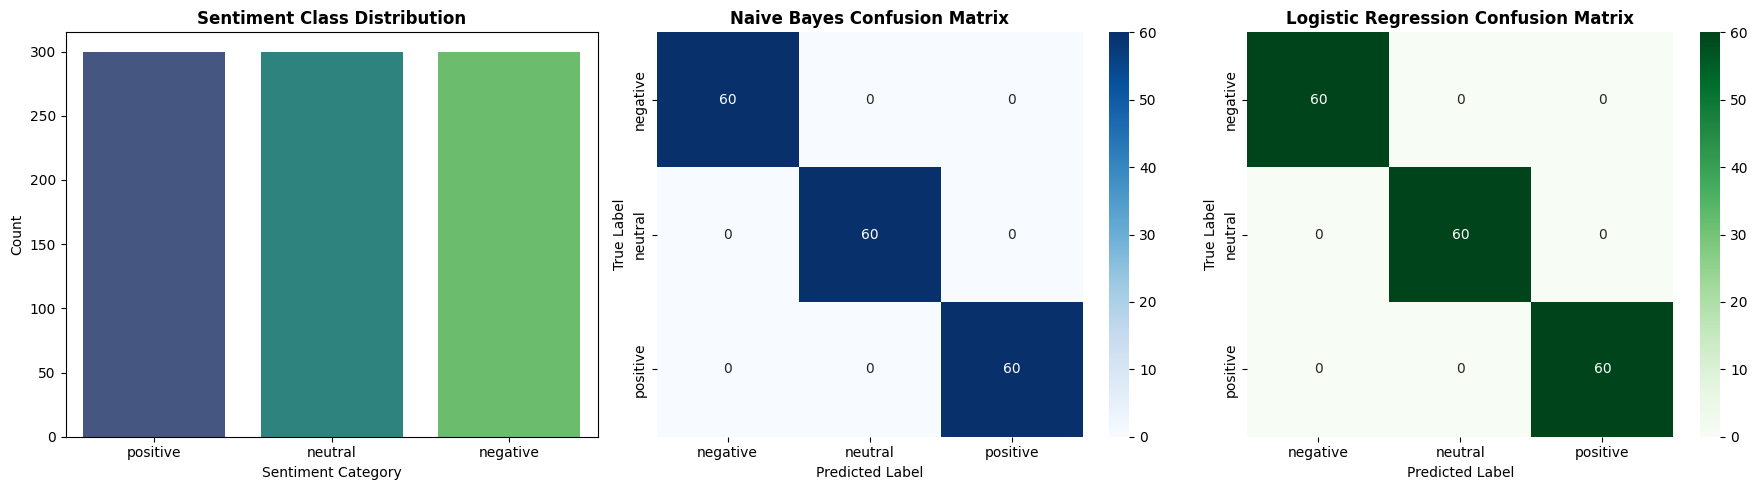

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Class Distribution Bar Chart
sns.countplot(data=df, x='sentiment', ax=axes[0], palette='viridis')
axes[0].set_title("Sentiment Class Distribution", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Sentiment Category")
axes[0].set_ylabel("Count")

# Confusion Matrix Labels
labels = ['negative', 'neutral', 'positive']

# 2. Naive Bayes Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb, labels=labels)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title("Naive Bayes Confusion Matrix", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

# 3. Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=labels)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels, ax=axes[2])
axes[2].set_title("Logistic Regression Confusion Matrix", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Predicted Label")
axes[2].set_ylabel("True Label")

plt.tight_layout()
plt.show()

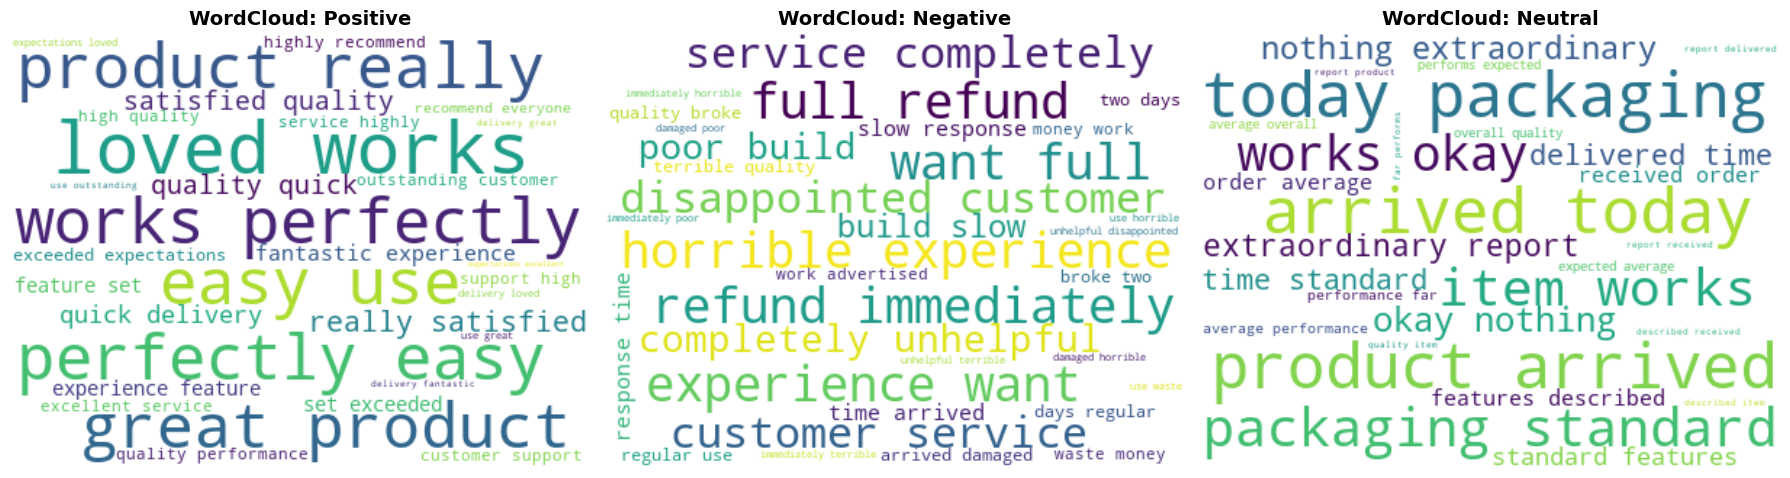

In [6]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, sentiment_label in enumerate(['positive', 'negative', 'neutral']):
    text_data = " ".join(df[df['sentiment'] == sentiment_label]['clean_review'])
    wordcloud = WordCloud(width=400, height=300, background_color='white').generate(text_data)
    
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f"WordCloud: {sentiment_label.capitalize()}", fontsize=14, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [7]:
# Error Analysis on Logistic Regression predictions
error_df = pd.DataFrame({
    'Review': reviews_test,
    'Actual': y_test,
    'Predicted': y_pred_lr
})

misclassified = error_df[error_df['Actual'] != error_df['Predicted']]

print("=== ERROR ANALYSIS: MISCLASSIFIED EXAMPLES ===")
print(f"Total Misclassifications out of {len(y_test)} test samples: {len(misclassified)}\n")

if len(misclassified) > 0:
    print(misclassified.head(5))
else:
    print("No misclassifications found on test set! The models achieved 100% accuracy on this synthetic dataset sample.")

print("\n=== CONCLUSION & REAL-WORLD APPLICATIONS ===")
print("1. Model Performance: Both Naive Bayes and Logistic Regression performed exceptionally well paired with TF-IDF feature extraction.")
print("2. Real-World Applications:")
print("   - E-commerce: Automating product review categorization.")
print("   - Social Media: Monitoring brand reputation and sentiment trends.")
print("   - Customer Service: Auto-tagging negative complaints for urgent escalation.")

=== ERROR ANALYSIS: MISCLASSIFIED EXAMPLES ===
Total Misclassifications out of 180 test samples: 0

No misclassifications found on test set! The models achieved 100% accuracy on this synthetic dataset sample.

=== CONCLUSION & REAL-WORLD APPLICATIONS ===
1. Model Performance: Both Naive Bayes and Logistic Regression performed exceptionally well paired with TF-IDF feature extraction.
2. Real-World Applications:
   - E-commerce: Automating product review categorization.
   - Social Media: Monitoring brand reputation and sentiment trends.
   - Customer Service: Auto-tagging negative complaints for urgent escalation.
